In [2]:
import torch
print(torch.__version__)

2.8.0+cu128


可以通过张量的shape属性来访问张量(沿每个轴的长度)的形状。

In [19]:
x = torch.arange(12)   #依次增大的广播数组
x
x.shape

torch.Size([12])

In [20]:
x.numel()  #算和

12

#改变一个张量的形状而不改变元素数量和元素值,可以调用reshape函数

12个元素变为三行四列

我们可以通过-1来调用此自动计算出维度的功能。即我们可以  用x.reshape(-1,4)或x.reshape(3,-1)来取代x.reshape(3,4)

In [21]:
X = x.reshape(3, 4)    #改变原有的形状
X

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

In [22]:
torch.zeros((2, 3, 4))   #全0

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])

In [23]:
torch.ones((2, 3, 4))    #全1

tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])

以下代码创建一个形状为(3,4)的张量。其中的  每个元素都从均值为0、标准差为1的标准高斯分布(正态分布)中随机采样

In [24]:
torch.randn(3, 4)

tensor([[-0.0079,  1.9112,  0.3844,  2.8854],
        [ 0.0580, -0.0605, -0.7874,  0.7679],
        [-2.3508, -0.3785,  0.8787, -1.2462]])

#运算操作


对于任意具有相同形状的张量,常见的标准算术运算符(+、-、*、/和**)都可以被升级为按元素运算。我  们可以在同一形状的任意两个张量上调用按元素操作


In [25]:
x = torch.tensor([1.0, 2, 4, 8])
y = torch.tensor([2, 2, 2, 2])
x + y, x - y, x * y, x / y, x ** y  # **运算符是求幂运算

(tensor([ 3.,  4.,  6., 10.]),
 tensor([-1.,  0.,  2.,  6.]),
 tensor([ 2.,  4.,  8., 16.]),
 tensor([0.5000, 1.0000, 2.0000, 4.0000]),
 tensor([ 1.,  4., 16., 64.]))

In [26]:
a=torch.exp(x)   #按元素指数操作
a

tensor([2.7183e+00, 7.3891e+00, 5.4598e+01, 2.9810e+03])

#torch.cat((X, Y), dim=0)
##将x和y按照垂直方向进行拼接（dim=0）

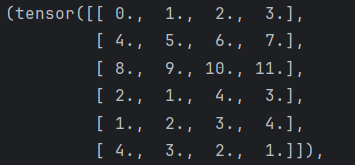

#torch.cat((X, Y), dim=1)
##将x和y按照水平方向进行拼接（dim=1）

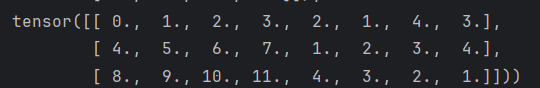


In [6]:
import torch
X = torch.arange(12, dtype=torch.float32).reshape((3,4))
Y = torch.tensor([[2.0, 1, 4, 3], [1, 2, 3, 4], [4, 3, 2, 1]])
print(X)
print(Y)
torch.cat((X, Y), dim=0), torch.cat((X, Y), dim=1)

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])
tensor([[2., 1., 4., 3.],
        [1., 2., 3., 4.],
        [4., 3., 2., 1.]])


(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [ 2.,  1.,  4.,  3.],
         [ 1.,  2.,  3.,  4.],
         [ 4.,  3.,  2.,  1.]]),
 tensor([[ 0.,  1.,  2.,  3.,  2.,  1.,  4.,  3.],
         [ 4.,  5.,  6.,  7.,  1.,  2.,  3.,  4.],
         [ 8.,  9., 10., 11.,  4.,  3.,  2.,  1.]]))

In [28]:
X.sum()

tensor(66)

最外层的列表对应于轴0,内层的列表对应于轴1
**分别演示了当我们沿行(轴‐0,形状的第一个元素)和按  列(轴‐1,形状的第二个元素)连结两个矩阵时,会发生什么情况。

In [9]:
X==Y

tensor([[False,  True, False,  True],
        [False, False, False, False],
        [False, False, False, False]])

In [10]:
X>Y

tensor([[False, False, False, False],
        [ True,  True,  True,  True],
        [ True,  True,  True,  True]])

In [11]:
X<Y

tensor([[ True, False,  True, False],
        [False, False, False, False],
        [False, False, False, False]])

##广播机制

我们仍然可以通过调用 广播机制(broadcasting mechanism)来执行按元素操作。这种机制的工作方式如下:

1. 通过适当复制元素来扩展一个或两个数组,以便在转换之后,两个张量具有相同的形状;
2. 对生成的数组执行按元素操作。
在大多数情况下,我们将沿着数组中长度为1的轴进行广播,如下例子:

In [29]:
a = torch.arange(3).reshape((3, 1))
b = torch.arange(2).reshape((1, 2))
a, b

(tensor([[0],
         [1],
         [2]]),
 tensor([[0, 1]]))

由于a和b分别是3 × 1和1 × 2矩阵,如果让它们相加,它们的形状不匹配。
我们将两个矩阵广播为一个更大的3 × 2矩阵,如下所示:矩阵a将复制列,矩阵b将复制行,然后再按元素相加

扩充为大小相同的矩阵

a=(tensor([[0，0],
           [1，1],
           [2，2]])

In [30]:
a+b

tensor([[0, 1],
        [1, 2],
        [2, 3]])

#索引和切片操作
**

In [34]:
X=torch.arange(12).reshape((3, 4))
X[-1], X[1:3]

(tensor([ 8,  9, 10, 11]),
 tensor([[ 4,  5,  6,  7],
         [ 8,  9, 10, 11]]))